# v1.1.3: Example 3 Soft Photon Evolution

In [529]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np
import astropy.units as u
import astropy.constants as c
from scipy.interpolate import interp1d

sys.path.append("../..")
from darkhistory.main import evolve
from darkhistory.config import load_data
from darkhistory.spec.spectrum import Spectrum
import darkhistory.physics as phys

import matplotlib as mpl
import matplotlib.pyplot as plt
# mpl.rc_file("../matplotlibrc")

# Test evolve

In [530]:
# Zero injection functions for baseline solution
photE = load_data('binning')['photeng']
elecEk = load_data('binning')['eleceng']
zero_phot_spec = Spectrum(photE, photE*0, spec_type='dNdE')
zero_elec_spec = Spectrum(elecEk, elecEk*0, spec_type='dNdE')

def zero_in_spec_phot(*args, **kwargs):
    return zero_phot_spec

def zero_in_spec_elec(*args, **kwargs):
    return zero_elec_spec

def zero_rate_func_N(*args, **kwargs):
    return 1e-100

def zero_rate_func_eng(*args, **kwargs):
    return 1e-100

In [531]:
soln_base = evolve(
    in_spec_phot  = zero_in_spec_phot, # [phot / inj]
    in_spec_elec  = zero_in_spec_elec, # [elec / inj]
    rate_func_N   = zero_rate_func_N,  # [inj / pcm^3 s]
    rate_func_eng = zero_rate_func_eng, # [eV / pcm^3 s]
    start_rs = 3000, end_rs = 100, coarsen_factor = 1, verbose = 1,
    clean_up_tf = False,
    reion_switch = True,
)
h = soln_base['softphot_hist'].history

[2025-11-21 16:00:42,176] INFO: darkhistory.config: Loaded deposition transfer functions.
[2025-11-21 16:00:45,706] INFO: darkhistory.config: Loaded ICS transfer functions.
 53%|█████▎    | 1799/3402 [00:37<00:28, 56.68it/s]

Injecting at z ~ 500.88


100%|██████████| 3402/3402 [01:18<00:00, 43.09it/s]


In [532]:
soln_base.keys()

dict_keys(['rs', 'x', 'Tm', 'highengphot', 'lowengphot', 'lowengelec', 'f', 'softphot_hist'])

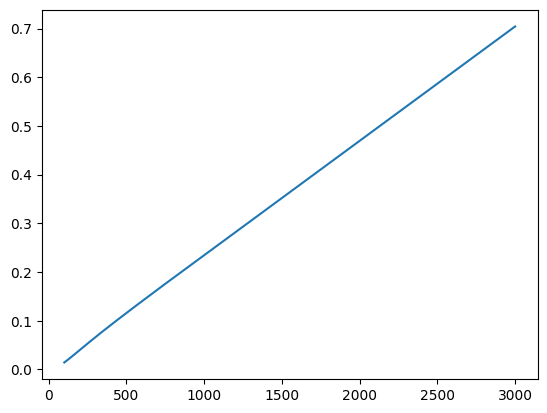

In [533]:
mpl.rcParams['text.usetex'] = False
plt.plot(soln_base['rs'], soln_base['Tm'])

In [534]:
z_arr = np.array([sd.z for sd in h])
n_arr = np.array([sd.n for sd in h])
n_interp = interp1d(z_arr, n_arr, kind='linear', bounds_error=True, axis=0)

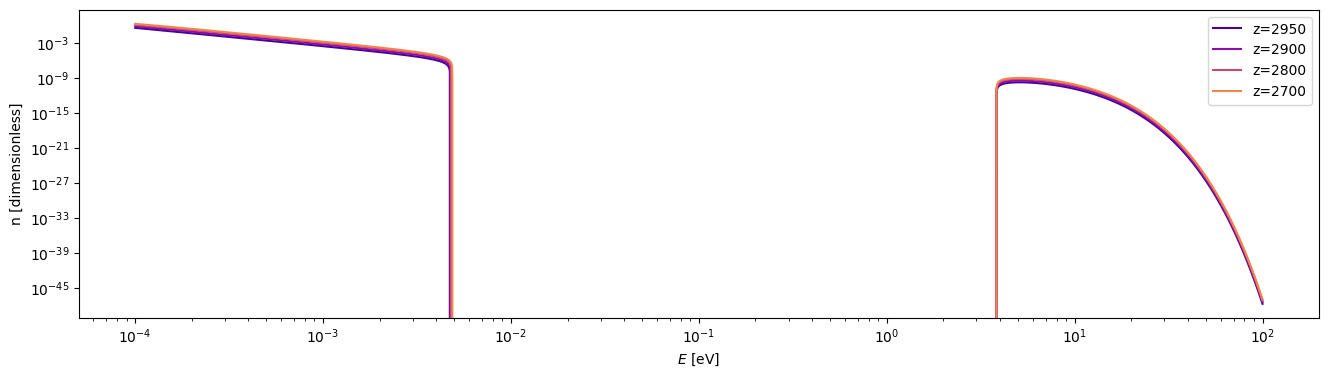

In [535]:
z_s = [2950, 2900, 2800, 2700]
color_s = mpl.colormaps['plasma']([0.1, 0.3, 0.5, 0.7])

fig, ax = plt.subplots(figsize=(16, 4))
sd = h[0]
for i_z, z in enumerate(z_s):
    ax.plot(sd.x, n_interp(z), label=f'z={z}', color=color_s[i_z])
ax.set(xlabel=r'$E$ [eV]', ylabel='n [dimensionless]')
ax.set(xscale='log', yscale='log')
ax.legend()

X_MIN_SOFTPHOT = 0.00010013834614982934
n_min, n_max = 2.7685032623444806e-35 566843749.8550472
dr_min, dr_max = 1.0117896363007764e-07 0.004437544750624061
len(rs) = 3402
len(dr) = 3402
Δ = 0
rs head: [3000.         2997.0014995  2994.005996   2991.01348651 2988.02396803]
dr head: [np.float64(0.004437544750624061), np.float64(5.477908938259634e-06), np.float64(5.472959577237674e-06), np.float64(5.463564090137671e-06), np.float64(5.454184445548781e-06)]
rs tail: [100.4206203  100.32024987 100.21997977 100.11980988 100.01974011]
dr tail: [np.float64(1.0259218092339192e-07), np.float64(1.0223694789405456e-07), np.float64(1.0188300395224979e-07), np.float64(1.0153034416770444e-07), np.float64(1.0117896363007764e-07)]


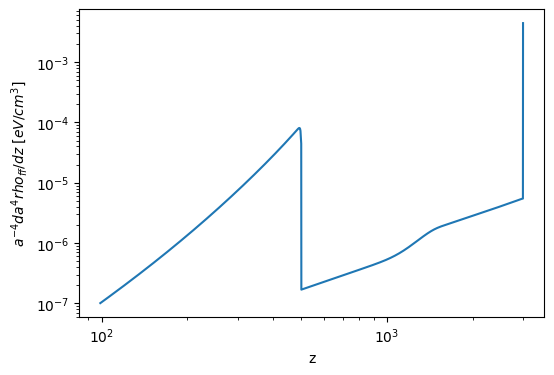

In [536]:
rs_arr = soln_base['rs']
z_arr  = rs_arr - 1

drhoffdz_arr = soln_base['softphot_hist'].drhoffdz_arr # ev / pcm^3 dz
#dTffdz_arr = (np.array(dTffdz_arr) * u.eV / c.k_B).to(u.K).value


print("X_MIN_SOFTPHOT =", soln_base['softphot_hist'].spec.x.min())
print("n_min, n_max =", np.nanmin(soln_base['softphot_hist'].spec.n),
                             np.nanmax(soln_base['softphot_hist'].spec.n))
print("dr_min, dr_max =", np.nanmin(drhoffdz_arr), np.nanmax(drhoffdz_arr))

print("len(rs) =", len(soln_base['rs']))
print("len(dr) =", len(soln_base['softphot_hist'].drhoffdz_arr))
print("Δ =", len(soln_base['rs']) - len(soln_base['softphot_hist'].drhoffdz_arr))

print("rs head:", soln_base['rs'][:5])
print("dr head:", soln_base['softphot_hist'].drhoffdz_arr[:5])

print("rs tail:", soln_base['rs'][-5:])
print("dr tail:", soln_base['softphot_hist'].drhoffdz_arr[-5:])




fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr, drhoffdz_arr, color='C0')
#ax.plot(z_arr, dTffdz_arr, color='C0')
#ax.plot(z_arr, -dTffdz_arr, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$a^{-4} d a^{4} rho_{ff} / dz$ [$eV / cm^3$]')
_ = ax.set(xscale='log', yscale='log') #yscale changed to linear
# ax.axvline(1500, color='k', lw=1)
#ax.set(ylim=(1e-2, 1e5))

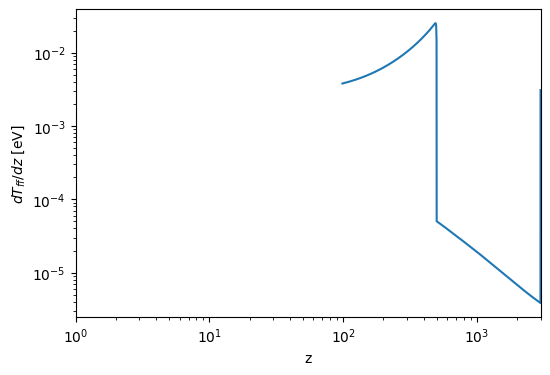

In [537]:
rs_arr = soln_base['rs']
z_arr  = rs_arr - 1

dr_arr = np.array(soln_base['softphot_hist'].drhoffdz_arr) * u.eV / u.cm**3

nH0 = phys.nH / u.cm**3
nH_arr = nH0 * rs_arr**3

# soln_base['x'] has shape (N,2)
xHII   = soln_base['x'][:, 0]
xHeII  = soln_base['x'][:, 1]
xe_arr = xHII + xHeII

chi = phys.chi
n_tot = nH_arr * (1 + chi + xe_arr)

dTffdz_arr = -(2 / (3 * c.k_B)) * dr_arr / n_tot
dTffdz_arr = dTffdz_arr.to(u.K).value


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr, -dTffdz_arr, color='C0')
#ax.plot(z_arr, -dTffdz_arr, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$d T_{ff} / dz$ [eV]')
ax.set(xlim=(1,3e3))
_ = ax.set(xscale='log', yscale='log') #yscale changed to linear
# ax.axvline(1500, color='k', lw=1)
#ax.set(ylim=(1e-2, 1e5))

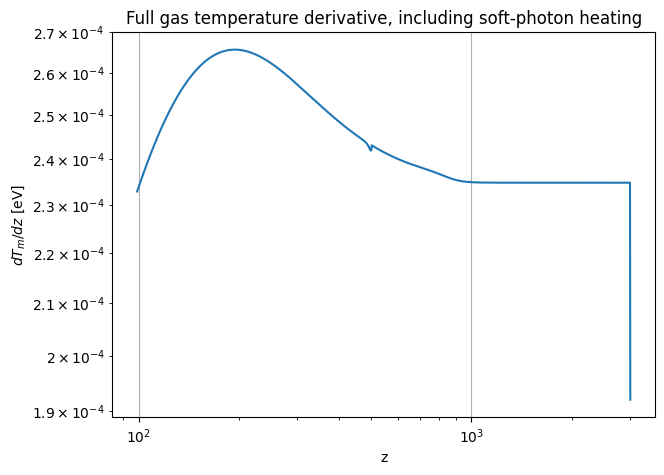

In [538]:
rs_arr = soln_base['rs']        # = 1+z
z_arr  = rs_arr - 1
Tm_arr = soln_base['Tm']        # matter temperature (eV)

# Compute derivative dT_m/dz numerically
dTmdz_arr = np.gradient(Tm_arr, z_arr)

# Plot
plt.figure(figsize=(7,5))
plt.plot(z_arr, dTmdz_arr, color='C0')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("z")
plt.ylabel(r"$dT_m/dz$ [eV]")
plt.title("Full gas temperature derivative, including soft-photon heating")
plt.grid(True)
plt.show()


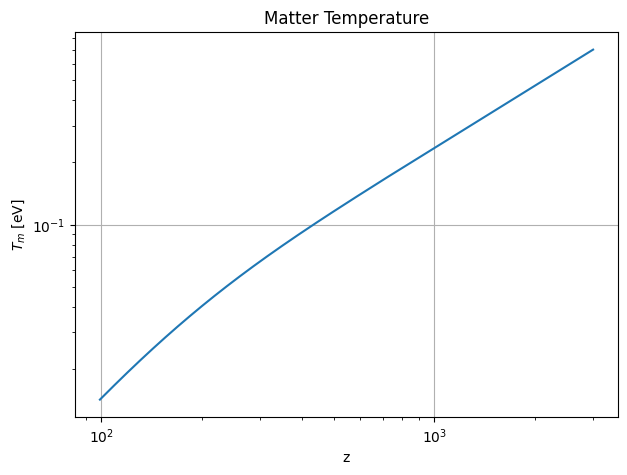

In [539]:
# Extract arrays
rs_arr = soln_base['rs']        # = 1+z
z_arr  = rs_arr - 1
Tm_arr = soln_base['Tm']        # matter temperature (eV)

plt.figure(figsize=(7,5))
plt.plot(z_arr, Tm_arr, color='C0')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("z")
plt.ylabel(r"$T_m$ [eV]")
plt.title("Matter Temperature")
plt.grid(True)
plt.show()


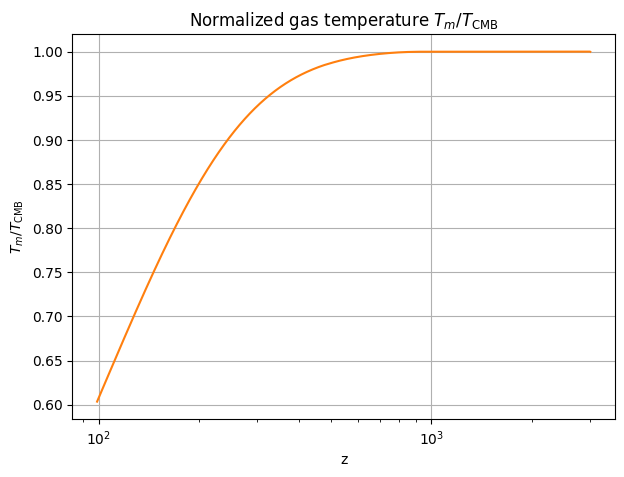

In [540]:
# Compute CMB temperature at each redshift (in eV)
T_CMB_arr = phys.TCMB(rs_arr)

# Normalized ratio
norm_T = Tm_arr / T_CMB_arr

# Plot
plt.figure(figsize=(7,5))
plt.plot(z_arr, norm_T, color='C1')
plt.xscale('log')
plt.xlabel("z")
plt.ylabel(r"$T_m/T_{\rm CMB}$")
plt.title(r"Normalized gas temperature $T_m/T_{\rm CMB}$")
plt.grid(True)
plt.show()


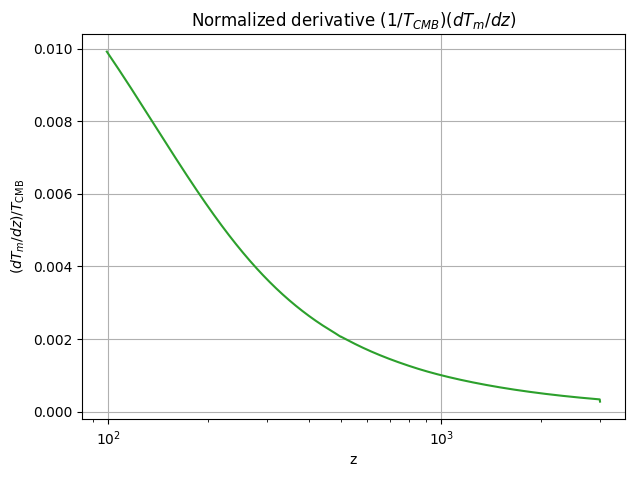

In [541]:
dTmdz_norm = dTmdz_arr / T_CMB_arr

plt.figure(figsize=(7,5))
plt.plot(z_arr, dTmdz_norm, color='C2')
plt.xscale('log')
plt.xlabel("z")
plt.ylabel(r"$(dT_m/dz)/T_{\rm CMB}$")
plt.title("Normalized derivative $(1/T_{CMB}) (dT_m/dz)$")
plt.grid(True)
plt.show()


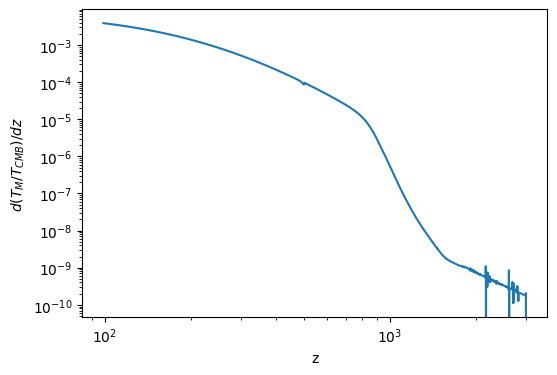

In [542]:
Tm_arr = soln_base['Tm']
TCMB_arr = np.array([phys.TCMB(1+z) for z in z_arr])


Tm_arr_sorted = Tm_arr[::-1]
TCMB_arr_sorted = TCMB_arr[::-1]

dTmTcmbdz = np.gradient(Tm_arr_sorted / TCMB_arr_sorted, z_arr[::-1])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr[::-1], dTmTcmbdz, color='C0')
#ax.plot(z_arr, -dTmTcmbdz, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$d(T_{M}/T_{CMB})/dz$')
_ = ax.set(xscale='log', yscale='log')

Text(0, 0.5, '$d(T_m/T_{\\rm CMB})/d\\ln z$')

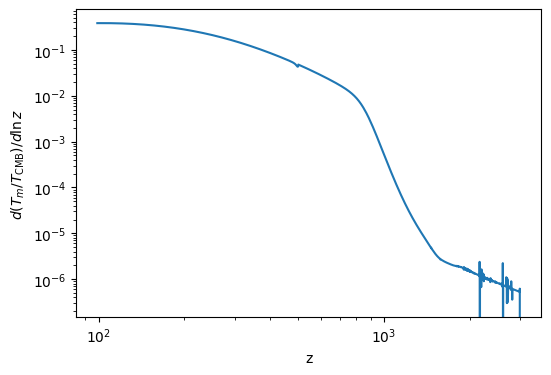

In [543]:
R      = Tm_arr_sorted / TCMB_arr_sorted
dRdz   = np.gradient(R, z_sorted)             # d(Tm/Tcmb)/dz
dR_dlnz = z_sorted * dRdz                     # d(Tm/Tcmb)/d ln z

plt.figure(figsize=(6,4))
plt.plot(z_sorted, dR_dlnz)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$d(T_m/T_{\rm CMB})/d\ln z$')


Text(0.5, 1.0, 'Total matter temperature evolution')

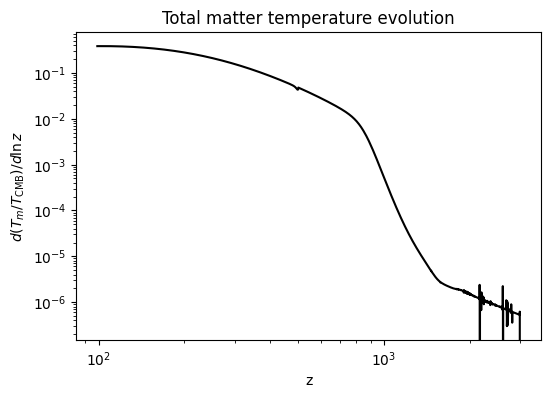

In [544]:
rs_arr = soln_base['rs']
z_arr  = rs_arr - 1
Tm     = soln_base['Tm']
Tcmb   = np.array([phys.TCMB(rs) for rs in rs_arr])

# sort so z increases
idx    = np.argsort(z_arr)
z      = z_arr[idx]
Tm     = Tm[idx]
Tcmb   = Tcmb[idx]

R      = Tm / Tcmb
dRdz   = np.gradient(R, z)
dR_dlnz = z * dRdz

plt.figure(figsize=(6,4))
plt.plot(z, dR_dlnz, color='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$d(T_m/T_{\rm CMB})/d\ln z$')
plt.title('Total matter temperature evolution')


Text(0, 0.5, 'Brems contribution: $d(T_m/T_{\\rm CMB})/d\\ln z$')

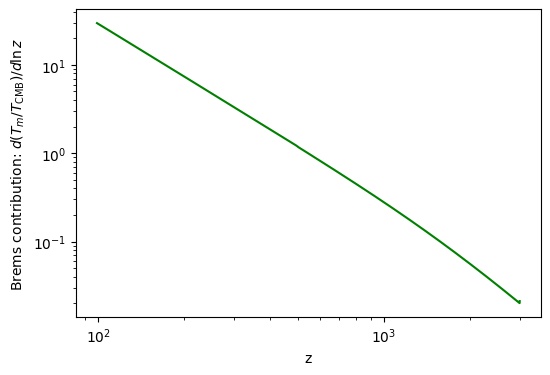

In [545]:
rs     = soln_base['rs']
z      = rs - 1
dr     = np.array(soln_base['softphot_hist'].drhoffdz_arr) * u.eV / u.cm**3

nH0    = phys.nH / u.cm**3
nH     = nH0 * rs**3
xHII   = soln_base['x'][:,0]
xHeII  = soln_base['x'][:,1]
xe     = xHII + xHeII
chi    = phys.chi
n_tot  = nH * (1 + chi + xe)

dTffdz = (-dr / (1.5 * n_tot)).to(u.eV).value   # ff-only piece of dTm/dz

Tcmb   = np.array([phys.TCMB(r) for r in rs])
R      = Tm / Tcmb
dTcmbdz = Tcmb / rs

# ff-only contribution to d(Tm/Tcmb)/dz:
dRdz_ff = -((dTffdz / Tcmb) - R * (dTcmbdz / Tcmb))

# and to d/d ln z:
dR_dlnz_ff = z * dRdz_ff

plt.figure(figsize=(6,4))
plt.plot(z, dR_dlnz_ff, color='g')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'Brems contribution: $d(T_m/T_{\rm CMB})/d\ln z$')


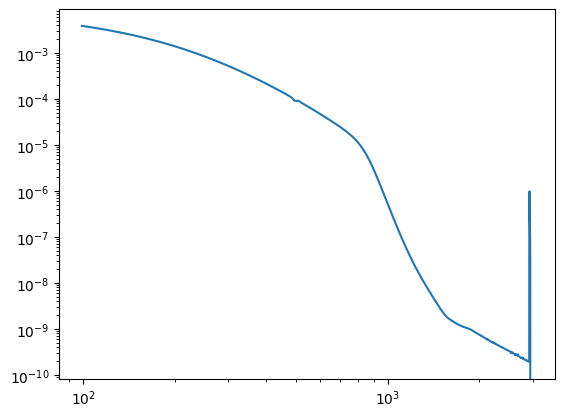

In [546]:
from scipy.signal import savgol_filter

R =  soln_base['Tm'] / np.array([phys.TCMB(1+z) for z in z_arr])

z_sorted = z_arr[::-1]
R_sorted = R[::-1]

R_smooth = savgol_filter(R_sorted, 51, 3)

dRdz = np.gradient(R_smooth, z_sorted)

plt.plot(z_sorted, dRdz)
plt.xscale('log'); plt.yscale('log')


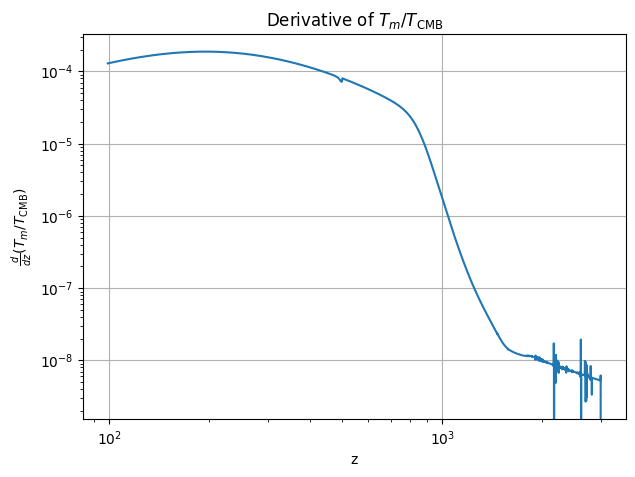

In [547]:
rs_arr = soln_base['rs']          # 1+z
z_arr  = rs_arr - 1
Tm_arr = soln_base['Tm']          # [eV]
T_CMB_arr = phys.TCMB(rs_arr)     # [eV]

# Ratio Tm / Tcmb
R_arr = - Tm_arr[::-1] / T_CMB_arr[::-1]

# d/dz of the ratio
dRdz_arr = np.gradient(R_arr, z_arr)

plt.figure(figsize=(7,5))
plt.plot(z_arr[::-1], dRdz_arr)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("z")
plt.ylabel(r"$\frac{d}{dz}\left(T_m/T_{\rm CMB}\right)$")
plt.title(r"Derivative of $T_m/T_{\rm CMB}$")
plt.grid(True)
plt.show()



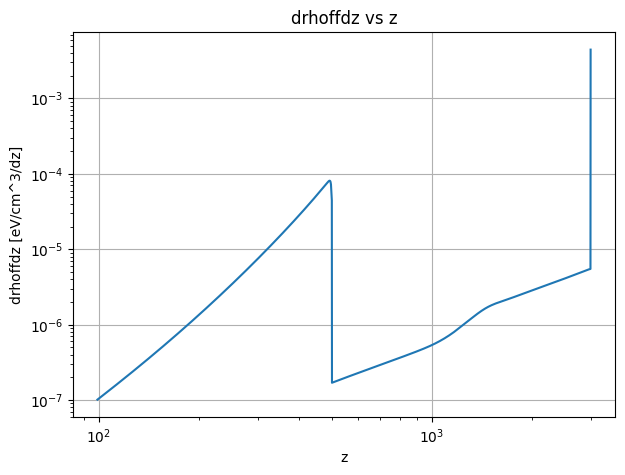

In [548]:
dr = np.array(soln_base['softphot_hist'].drhoffdz_arr)
z = soln_base['rs'] - 1

plt.figure(figsize=(7,5))
plt.plot(z, dr)
plt.xscale('log')
plt.title("drhoffdz vs z")
plt.xlabel("z")
plt.ylabel("drhoffdz [eV/cm^3/dz]")
plt.yscale('log')
plt.grid(True)
plt.show()

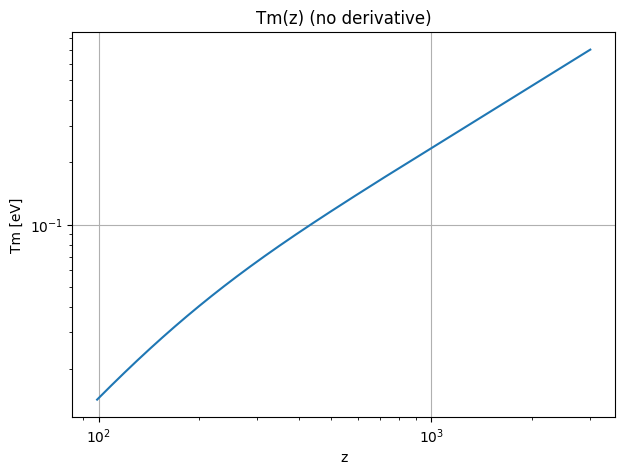

In [549]:
Tm = soln_base['Tm']
z  = soln_base['rs'] - 1

plt.figure(figsize=(7,5))
plt.plot(z, Tm)
plt.xscale('log')
plt.title("Tm(z) (no derivative)")
plt.xlabel("z")
plt.ylabel("Tm [eV]")
plt.yscale('log')
plt.grid(True)
plt.show()

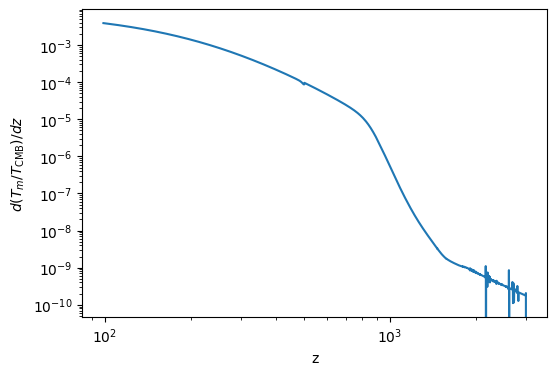

In [550]:
rs_arr = soln_base['rs']            # 1+z
z_arr  = rs_arr - 1
Tm_arr = soln_base['Tm']            # [eV]
Tcmb_arr = np.array([phys.TCMB(rs) for rs in rs_arr])  # [eV]

# ---- sort so z increases ----
idx = np.argsort(z_arr)
z = z_arr[idx]
Tm = Tm_arr[idx]
Tcmb = Tcmb_arr[idx]
rs = rs_arr[idx]   # same as 1+z

# ---- compute derivatives ----
# dT_m/dz numerically (Tm is smooth, so this is stable)
dTmdz = np.gradient(Tm, z)

# analytic dTcmb/dz = Tcmb / (1+z)
dTcmbdz = Tcmb / rs

# ratio and its derivative:
R = Tm / Tcmb
dRdz = (dTmdz / Tcmb) - R * (dTcmbdz / Tcmb)   # = d/dz(Tm/Tcmb)

# ---- plot ----
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(z, dRdz, color='C0')
ax.set(xlabel='z', ylabel=r'$d(T_m/T_{\rm CMB})/dz$')
ax.set(xscale='log', yscale='log')
plt.show()


In [551]:
soln_base.keys()

dict_keys(['rs', 'x', 'Tm', 'highengphot', 'lowengphot', 'lowengelec', 'f', 'softphot_hist'])

In [552]:
soln_base['Tm'].shape

(3402,)

In [553]:
np.array([phys.TCMB(1+z) for z in z_arr[2:]]).shape

(3400,)

In [554]:
a = np.diff(soln_base['Tm'] / np.array([phys.TCMB(1+z) for z in z_arr[2:]]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr[3:], a, color='C0')
ax.plot(z_arr[3:], -a, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$dT_{ff}/dz$ [K]')
ax.set(xscale='log', yscale='log')
# ax.axvline(1500, color='k', lw=1)
# ax.set(ylim=(1e-2, 1e5))

ValueError: operands could not be broadcast together with shapes (3402,) (3400,) 

In [ ]:
for i in range(100):
    print(f'{h[i].z:.3f}, {h[i].tau:.6e}')

# MISC tests

In [ ]:
z = 10
n_H = phys.nH * (1 + z)**3 * (1/u.cm**3)
n_He = phys.nHe * (1 + z)**3 * (1/u.cm**3)
n_e = n_H * 0.5
prefactorEq14 = - 1 / (3/2 * (n_H + n_He + n_e))

T_CMB = phys.TCMB(1 + z) * u.eV
rho_CMB = (np.pi**2 / 15 * (T_CMB)**4 / (c.hbar**3 * c.c**3)).to(u.eV / u.cm**3)
T_M = 10 * u.eV
H = phys.hubble(z) * u.s**-1
prefactorEq15 = - rho_CMB / (np.pi**4/15) * (T_M/T_CMB)**3 * c.sigma_T * n_e * c.c / (H * (1 + z))

a = (prefactorEq14 * prefactorEq15 * 1).to(u.eV)

In [12]:
(a / u.eV).decompose()

<Quantity 3.36814609e+14>

In [13]:
prefactor.decompose()

<Quantity -0.03237836 kg / (m s2)>